Sequence 1: lowest energy = -2.0, success probability = 1.00
Lowest energy found: -2.0
Successes: 20
Success probability: 1.0
1.0
Sequence 2: lowest energy = -5.0, success probability = 0.25
Lowest energy found: -5.0
Successes: 5
Success probability: 0.25
0.25
Sequence 3: lowest energy = -7.0, success probability = 0.55
Lowest energy found: -7.0
Successes: 11
Success probability: 0.55
0.55
Sequence 4: lowest energy = -7.0, success probability = 0.20
Lowest energy found: -7.0
Successes: 4
Success probability: 0.2
0.2
Sequence 5: lowest energy = -7.0, success probability = 0.05
Lowest energy found: -7.0
Successes: 1
Success probability: 0.05
0.05
Sequence 6: lowest energy = -5.0, success probability = 0.60
Lowest energy found: -5.0
Successes: 12
Success probability: 0.6
0.6
Sequence 7: lowest energy = -7.0, success probability = 0.15
Lowest energy found: -7.0
Successes: 3
Success probability: 0.15
0.15
Sequence 8: lowest energy = -9.0, success probability = 0.05
Lowest energy found: -9.0

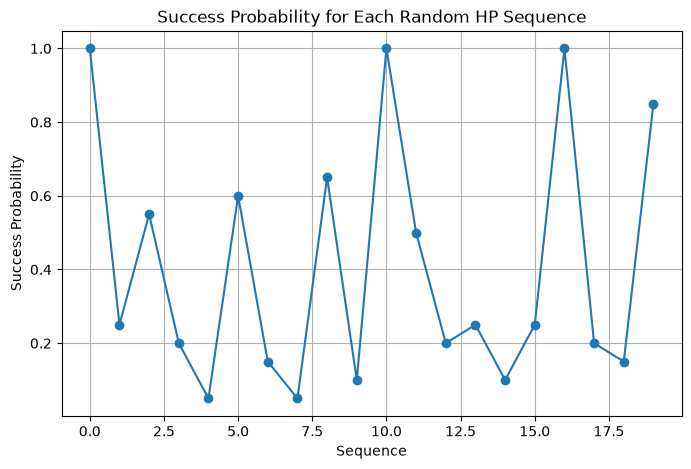

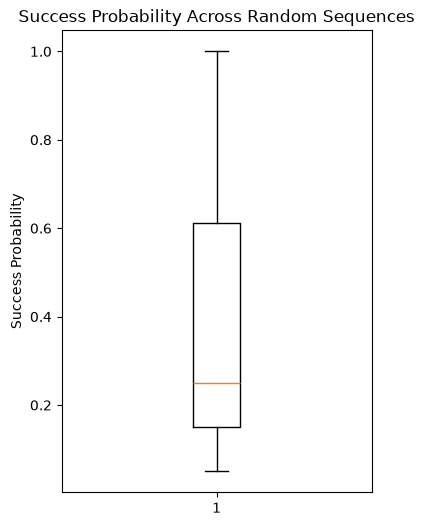

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Functions import ( laydowncoordinates, compute_A,energy, propose_move, valid_fold)

num_sequences = 20
H=1
P=0

sequence_success_probabilities = []

for seq in range(num_sequences):
    #generate random sequence
    Gamma = np.random.randint(0, 2, size=20).tolist()
    A = compute_A(Gamma)
    N = len(Gamma)
    num_trials = 20
    best_energies_all= []

    for trial in range(num_trials):
        #generate random sequence d
        while True:
            d = np.random.randint(0, 4, size=N-1)
            coordinates = laydowncoordinates(d)
            if valid_fold(coordinates):
                break
        #initialize values for SA
        E = energy(coordinates, Gamma, A, H)
        best_E = E
        energies = []
        best_coordinates = coordinates.copy()
        best_d = d.copy()
        #parameters for SA
        num_sweeps = 10000
        beta = np.linspace(0.1, 10, num_sweeps)

        for i in range(num_sweeps):
            #new proposals
            while True:
                d_new = propose_move(d)
                coords_new = laydowncoordinates(d_new)
                if valid_fold(coords_new):
                    break
            #rule for accepting proposal
            E_new = energy(coords_new, Gamma, A, H)
            deltaE = E_new - E
            if deltaE <= 0:
                d = d_new
                coordinates = coords_new
                E = E_new
            elif np.random.rand() < np.exp(-deltaE * beta[i]):
                d = d_new
                coordinates = coords_new
                E = E_new
            #after each MCS, calculate the energy
            energies.append(E)
            #find the best energies and corresponding folds
            if E < best_E:
                best_E = E
                best_coordinates = coordinates.copy()
                best_d = d.copy()
        #best energy per trial to calculate the success prob
        best_energies_all.append(best_E)

    #per sequence, what is the amount of times we reach the lowest energy in the trial?
    lowest_energy = min(best_energies_all)
    successes = sum(E == lowest_energy for E in best_energies_all)
    success_probability = successes / num_trials
    sequence_success_probabilities.append(success_probability)

    print(
    f"Sequence {seq + 1}: "
    f"lowest energy = {lowest_energy}, "
    f"success probability = {success_probability:.2f}")

    print("Lowest energy found:", lowest_energy)
    print("Successes:", successes)
    print("Success probability:", success_probability)
    print(success_probability)



#on average, what was the probability that we reach the lowest energy across different sequences and trials
average_success = np.mean(sequence_success_probabilities)

print(average_success)
plt.figure(figsize=(8,5))
plt.plot(sequence_success_probabilities, 'o-')
plt.xlabel("Sequence")
plt.ylabel("Success Probability")
plt.title("Success Probability for Each Random HP Sequence")
plt.grid(True)
plt.show()

#box plot
plt.figure(figsize=(4,6))
plt.boxplot(sequence_success_probabilities)
plt.ylabel("Success Probability")
plt.title("Success Probability Across Random Sequences")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
num_bootstrap = 10000
bootstrap_means = []

for _ in range(num_bootstrap):
    sample = np.random.choice(
        sequence_success_probabilities,
        size=len(sequence_success_probabilities),
        replace=True)

    bootstrap_means.append(np.mean(sample))
#95%confidence interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print(f"Average success probability = {average_success:.3f}")
print(f"95% Confidence Interval = [{lower:.3f}, {upper:.3f}]")

Average success probability = 0.405
95% Confidence Interval = [0.268, 0.555]


In [ ]:
plt.figure(figsize=(8,5))
plt.hist(bootstrap_means, bins=30)

plt.axvline(average_success, linestyle="--", linewidth=2, label="Mean")
plt.axvline(lower, linestyle=":", linewidth=2, label="95% CI")
plt.axvline(upper, linestyle=":", linewidth=2)
plt.xlabel("Mean Success Probability")
plt.ylabel("Bootstrap Count")
plt.title("Bootstrap Distribution")
plt.legend()
plt.grid(True)

plt.show()